## Adjust SFNO ensemble data towards ERA5 before calculating RPs for Storm Desmond

- Read in datasets and process the input files 
- Produce simple plots of ERA5
- Identify the SFNO forecasts that are most similar to ERA5 around the time of the event (5-6 December 2015)
- Calculate the distribution of mslp and precip in these forecasts and compare with ERA5 
- Use the differences in these distributions to calculate a scale factor that we can apply to address the issue of low precip

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import math
import regionmask
sns.set_theme()
import logging
from pathlib import Path
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

import os
import re
import pandas as pd
import matplotlib.dates as mdates
import metpy.plots.ctables as mp
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors

import matplotlib as mpl
from matplotlib.colors import ListedColormap, BoundaryNorm
from statsmodels.distributions.empirical_distribution import ECDF

import plotting_functions as pf

## Load metadata from the config file

- `file_path`, `date_str`, `event_name`

In [2]:
config_file_path = '/mnt/data/data_analysis/config.json'
events = pf.load_config(config_file_path)
event_str = 'Desmond_seed76_v2' # ['21Aug2015', '22Aug2015', 'Charley_20Aug1986', 'Desmond', 'Desmond_seed76', 'event_response'] 
file_path = events[event_str]['path']
files = sorted(glob.glob(f'{file_path}/*.nc'))
date_str = events[event_str]['date_str']
event_name = events[event_str]['name']

## Pre-process the ERA5 data to calculate accumulated precipitation

In [3]:
# repeat for precip data
era5_prcp_path = '/mnt/data/era5/era5_precip_041215_061215.grib'
era5_ds_pr = xr.open_dataset(era5_prcp_path,engine='cfgrib')
era5_rolling_window = 48
era5_min_periods = era5_rolling_window
lead_dim = 'valid_time'

era5_roll = pf.preprocess_era5_grib(era5_ds_pr,
                                    rolling_window=era5_rolling_window,
                                    min_periods=era5_min_periods,
                                    lead_dim=lead_dim)

Ignoring index file '/mnt/data/era5/era5_precip_041215_061215.grib.5b7b6.idx' older than GRIB file


## Call the function that identifies the peak time for each ensemble member

- Apply pre-processing (within `top_members_by_rolling_max`)
    - `select_subset_by_bbox`
    - `sfno_land_sea_mask`
    - `normalise_longitude`
    - `calculate_rolling_total`
- Create a single distribution from these forecasts

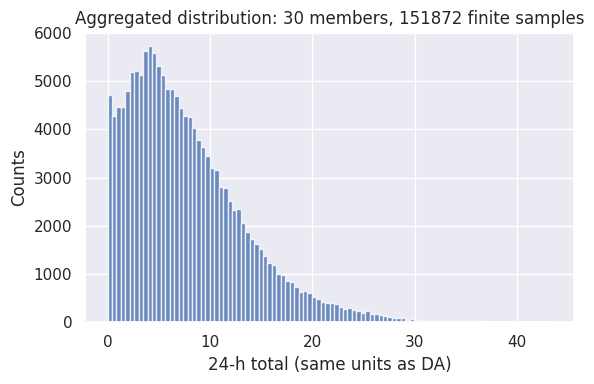

In [ ]:
# match the SFNO rolling window variables to match ERA5 (take into account different output interval)
if era5_rolling_window == 48:
    sfno_rolling_window = 8 # SFNO data has 6 h intervals; 4 --> 24 h rolling totals, 8 --> 48 h rolling totals, ...
    sfno_min_periods = 8 
elif era5_rolling_window == 24:
    sfno_rolling_window = 4 
    sfno_min_periods = 4

cdf_bbox = [-11, 1.5, 50.25, 60] # ERA5 only extends to 60N, so match that value 

# identify the peak time for each ensemble member and calculate the top members by rolling max precip in the score_bbox region
# also plot the distribution of rolling max precip across all members and the histogram of peak positions
# 'score_bbox' represents the region we use to calculate our 'extremes'
top_members, peak_positions, fig_none, da_tp_roll, sfno_vals_full, blocks, fig_hist = pf.top_members_by_rolling_max(
    files,
    event_str=event_str,
    sampling_dims='member',
    lead_dim_hint='lead_time',
    rolling_window=sfno_rolling_window,
    min_periods=sfno_min_periods,
    score_bbox=cdf_bbox,
    plot_bbox=cdf_bbox,
    exclusion_window=2,
    top_k=10,
    cmap=pf.get_metpy_colourmap('precipitation'),
    crs=ccrs.PlateCarree(),
    ncols=5,
    panel_size=2.2, # 2.2
    compute_now=True,
    peak_window_hours=48,
    plot_distribution=True
)

## Call the `top_members_by_rolling_max` function again 

- Use the original functionality to plot the accumulated precip for the most extreme lead time values 
- UPDATE: don't need to open this notebook to plot the adjusted, accumulated precip - that's found in the output file I produce in the cells below

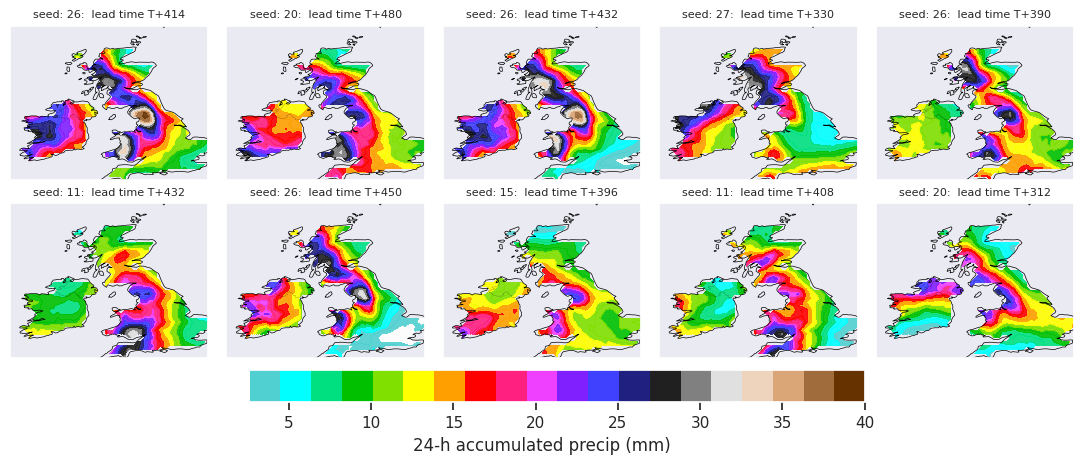

In [7]:
# call the function again but for the original functionality 
top_members, peak_positions, fig, da_tp_roll = pf.top_members_by_rolling_max(
    files,
    event_str=event_str,
    sampling_dims='member',
    lead_dim_hint='lead_time',
    rolling_window=sfno_rolling_window,
    min_periods=sfno_min_periods,
    score_bbox=cdf_bbox,
    plot_bbox=cdf_bbox,
    exclusion_window=2,
    top_k=10,
    cmap=pf.get_metpy_colourmap('precipitation'),
    crs=ccrs.PlateCarree(),
    ncols=5,
    panel_size=2.2, # 2.2
    compute_now=True,
    peak_window_hours=None,
    plot_distribution=True
)

## Apply the quantile mapping function and write the adjusted SFNO data to a new nc file

- Single ERA5 and single SFNO distribution 
- Apply quantile mapping function 
- Write adjusted SFNO data to a new nc file 

In [ ]:
# parent directory output path
out_dir = '/mnt/data/sfno/Desmond_seed76_v2/adjusted/'
os.makedirs(out_dir, exist_ok=True)

# event end time (depends on accumulation window)
if era5_rolling_window == 24:
    event_end_time = '2015-12-06T00'
elif era5_rolling_window == 48:
    event_end_time = '2015-12-06T12'

# preprocess ERA5 
era5_pr_land = pf.land_sea_mask(era5_roll)
era5_pr_land, _, _ = pf.select_subset_by_bbox(era5_pr_land, bbox=cdf_bbox)
era5_pr_land = era5_pr_land.sel(valid_time=event_end_time)
era5_vals_flat = era5_pr_land.values.ravel()

# sense check the output before writing to nc file 
print('sfno pooled (full) length: ',sfno_vals_full.size)
print('era5 pooled length: ', era5_vals_flat.size)

# build mapping using quantile_map and make sure that array sizes are equal 
mapped_pool, mapper = pf.quantile_map(sfno_vals_full, era5_vals_flat, n_quantiles=11)
assert mapped_pool.size == sfno_vals_full.size

# reconstruct the original mapped blocks into a full 4D array 
out_arr = np.array(da_tp_roll.values, dtype=float)

# prepare split indices from blocks lengths 
lengths = [b['length'] for b in blocks]
# split the mapped_pool into block-sized arrays (order must match blocks list)
splits = np.split(mapped_pool, np.cumsum(lengths)[:-1])

# iterate and assign each block back (the shapes and positions are stored in blocks)
for b, s in zip(blocks, splits):
    m = b['member']
    start = b['start']
    end = b['end']
    shape = b['shape']
    arr_block = s.reshape(shape)
    # assign back into out_arr at [member, start:end, :, :]
    out_arr[m, start:end, :, :] = arr_block

# wrap into an xr.da with the same coords + dims as 'da_tp24' 
mapped_da = xr.DataArray(
    out_arr,
    coords=da_tp_roll.coords,
    dims=da_tp_roll.dims,
    name='precip_adjusted'
)

# preserve attributes and add a note 
mapped_da.attrs.update(da_tp_roll.attrs)
mapped_da.attrs['quantile_mapped_to'] = 'ERA5'
mapped_da.attrs['quantile_map_nq'] = 11

# UNCOMMENT TO WRITE DATA TO NC FILE 
# # save to netcdf 
# ds_out = mapped_da.to_dataset(name='precip_adjusted')
# fname = f'{event_str}_{era5_rolling_window}h_{event_end_time}_sfno_adjusted.nc'
# outpath = os.path.join(out_dir, fname)
# print("Writing:", outpath)
# pf.sanitize_and_write(ds_out, outpath, varname='precip_adjusted')
# print("Wrote", outpath)

sfno pooled (full) length:  507960
era5 pooled length:  2040


## Also write just the 48-h windows to nc file 

- Might be easier for future processing 

In [6]:
lat_dim, lon_dim = pf.extract_coord_names(da_tp_roll)

n_blocks = len(blocks)
nlat = da_tp_roll.sizes[lat_dim]; nlon = da_tp_roll.sizes[lon_dim]
max_len = max(b['shape'][0] for b in blocks)

padded_blocks = np.full((n_blocks, max_len, nlat, nlon), np.nan, dtype=float)
block_member = np.empty(n_blocks, dtype=int)
block_start = np.empty(n_blocks, dtype=int)
block_end = np.empty(n_blocks, dtype=int)

for i, b in enumerate(blocks):
    m = b['member']; s = b['start']; e = b['end']
    shape = b['shape']
    arr_block = out_arr[m, s:e, :, :]   # mapped values already written to out_arr or directly from splits
    len_block = arr_block.shape[0]
    padded_blocks[i, :len_block, :, :] = arr_block
    block_member[i] = m
    block_start[i] = s
    block_end[i] = e

blocks_da = xr.DataArray(padded_blocks,
                         coords={'block': np.arange(n_blocks),
                                 'lead_rel': np.arange(max_len),
                                 lat_dim: da_tp_roll[lat_dim],
                                 lon_dim: da_tp_roll[lon_dim]},
                         dims=('block', 'lead_rel', lat_dim, lon_dim),
                         name='precip_adjusted')

# attach metadata so you know where blocks came from
blocks_da = blocks_da.assign_coords(block_member=('block', block_member),
                                    block_start=('block', block_start),
                                    block_end=('block', block_end))

# UNCOMMENT TO WRITE DATA TO NC FILE 
# ds_windows = blocks_da.to_dataset()
# out_dir = '/mnt/data/sfno/Desmond_seed76_v2/adjusted/'
# fname = f'{event_str}_sfno_adjusted_{era5_rolling_window}h_windows.nc'
# outpath_windows = os.path.join(out_dir, fname)
# print("Writing:", outpath_windows)
# pf.sanitize_and_write(ds_windows, outpath_windows, varname='precip_adjusted')

## Compare the spatial fields before and after adjustment 

In [7]:
sfno_adjusted = xr.open_dataset(f'/mnt/data/sfno/{event_str}/adjusted/{event_str}_sfno_adjusted_{era5_rolling_window}h_windows.nc')

In [9]:
sfno_adjusted

<xarray.Dataset> Size: 2MB
Dimensions:          (block: 30, lead_rel: 9, lat: 40, lon: 51)
Coordinates:
  * block            (block) int64 240B 0 1 2 3 4 5 6 7 ... 23 24 25 26 27 28 29
  * lead_rel         (lead_rel) int64 72B 0 1 2 3 4 5 6 7 8
  * lat              (lat) float64 320B 50.25 50.5 50.75 ... 59.5 59.75 60.0
  * lon              (lon) float64 408B -11.0 -10.75 -10.5 ... 1.0 1.25 1.5
    block_member     (block) int64 240B ...
    block_start      (block) int64 240B ...
    block_end        (block) int64 240B ...
Data variables:
    precip_adjusted  (block, lead_rel, lat, lon) float32 2MB ...

## LEGACY CODE 

In [8]:
# def sanitize_and_write(ds_out, 
#                        outpath, 
#                        varname=None, 
#                        compress=True, 
#                        complvl=4):
#     """
#     Make ds_out safe for to_netcdf:
#       - drop or convert object/tuple coords to strings
#       - convert single-element numpy arrays in coords to Python scalars
#       - convert array-like attrs to strings or scalars
#       - cast data variables to float32 (optional)
#     Then write ds_out to outpath with optional compression.
#     """
#     # make a copy to avoid mutating input
#     ds = ds_out.copy()

#     # --- clean coordinates ---
#     for cname in list(ds.coords):
#         val = ds.coords[cname].values
#         # object dtype (likely tuple(s) or object arrays)
#         if isinstance(val, np.ndarray) and val.dtype == object:
#             if val.size == 1:
#                 # convert 0-d object array (e.g. tuple) to a safe string
#                 try:
#                     scalar = val.item()
#                     # if tuple/list, format nicely
#                     if isinstance(scalar, (tuple, list)):
#                         ds = ds.assign_coords({cname: str(tuple(int(x) if hasattr(x,'__int__') else x for x in scalar))})
#                     else:
#                         ds = ds.assign_coords({cname: str(scalar)})
#                 except Exception:
#                     ds = ds.reset_coords(cname, drop=True)
#             else:
#                 # multi-element object array -> drop it (can't safely write)
#                 ds = ds.reset_coords(cname, drop=True)

#         # numeric 0-d arrays -> convert to python scalar value
#         elif isinstance(val, np.ndarray) and val.size == 1:
#             try:
#                 ds = ds.assign_coords({cname: val.item()})
#             except Exception:
#                 # fallback to string
#                 ds = ds.assign_coords({cname: str(val.ravel()[0])})

#         # if val is a numpy scalar (not ndarray)
#         elif hasattr(val, 'dtype') and np.isscalar(val) and isinstance(val, (np.generic,)):
#             try:
#                 ds = ds.assign_coords({cname: np.asscalar(val)})  # np.asscalar is deprecated, but assign_coords will accept python scalar
#             except Exception:
#                 try:
#                     ds = ds.assign_coords({cname: val.item()})
#                 except Exception:
#                     ds = ds.assign_coords({cname: str(val)})

#     # If you specifically want to remove the 'member' coord (common when writing per-member files):
#     if 'member' in ds.coords:
#         # either drop it:
#         ds = ds.reset_coords('member', drop=True)
#         # Or alternatively convert to a string label instead of dropping:
#         ds = ds.assign_coords(member=f"seed{seed:03d}_ens{ens}")

#     # --- clean attributes ---
#     for k, v in list(ds.attrs.items()):
#         if isinstance(v, np.ndarray):
#             if v.size == 1:
#                 ds.attrs[k] = v.item()
#             else:
#                 ds.attrs[k] = str(v.tolist())
#         elif isinstance(v, (list, tuple)):
#             ds.attrs[k] = str(v)
#         # else: leave scalar/string attrs as-is

#     # --- ensure datavars are numeric (cast to float32 to match encoding)
#     for var in ds.data_vars:
#         try:
#             ds[var] = ds[var].astype('float32')
#         except Exception:
#             pass

#     # --- build encoding ---
#     if varname is None:
#         data_vars = list(ds.data_vars)
#     else:
#         data_vars = [varname] if varname in ds.data_vars else list(ds.data_vars)
#     encoding = {}
#     for v in data_vars:
#         if compress:
#             encoding[v] = {'zlib': True, 'complevel': complvl, 'dtype': 'float32'}
#         else:
#             encoding[v] = {'dtype': 'float32'}

#     # write
#     ds.to_netcdf(outpath, mode='w', format='NETCDF4', encoding=encoding)
#     return outpath